<a href="https://colab.research.google.com/github/MegaliOrexi/CSCI323/blob/Week1/7776664_Lab1_Solved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Refrences**
[Data cleaning libraries:](https://www.stratascratch.com/blog/python-libraries-for-data-clean-up/) <br>
[Panda’s Alternatives](https://www.kaggle.com/discussions/general/330402)<br>
[Data Cleaning](https://github.com/microsoft/ML-For-Beginners/tree/main/4-Classification/1-Introduction)<br>
[Ibmlearn for imbalanced data](https://imbalanced-learn.org/stable/)<br>
[Mushroom dataset](https://archive.ics.uci.edu/dataset/73/mushroom)<br>
[Phishing website](https://archive.ics.uci.edu/dataset/327/phishing+websites)

# **TASK0:**
Run and underestand below codes

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

In [ ]:
#drag and drop the file to colab folders
df  = pd.read_csv('/content/cuisines.csv')

In [ ]:
df.head()

,Unnamed: 0,cuisine,almond,angelica,anise,anise_seed,apple,apple_brandy,apricot,armagnac,...,whiskey,white_bread,white_wine,whole_grain_wheat_flour,wine,wood,yam,yeast,yogurt,zucchini
0,65,indian,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,66,indian,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,67,indian,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,68,indian,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,69,indian,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


## **TASK1:**
Question 1. what does below code do? <br>
#**Ans: it accesses the dataframe then the specific column cuisine, it then counts the different values in the column and then displays it on a horizontal bar chart**    <br> <br>
Question 2. are we using matplot lib to plot the graph? <br>
#**Ans: Yes, we use the pandas library library which uses the matplotlib library under the hood** <br> <br>
Question 3. convert the graph into pie chart and show the percentage of destribution

<Axes: ylabel='cuisine'>

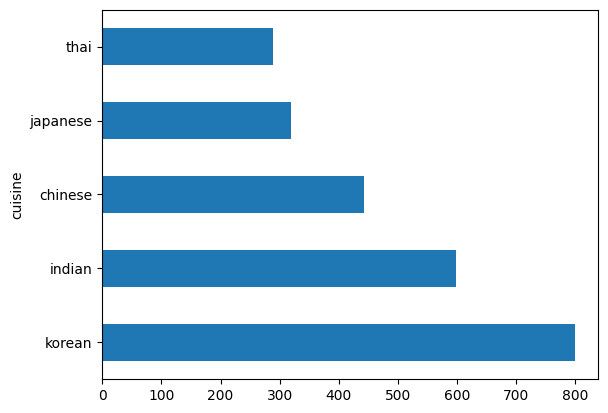

In [ ]:
df.cuisine.value_counts().plot.barh()

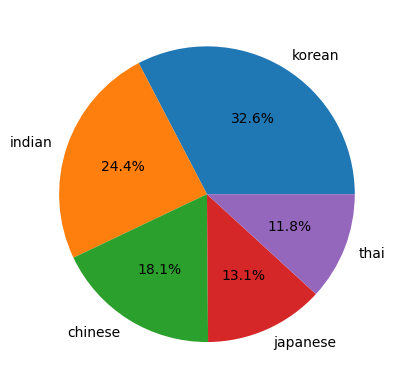

In [ ]:
#Question3
df.cuisine.value_counts().plot.pie(autopct='%1.1f%%')
plt.ylabel('')
plt.show()

## **TASK2:**
Now let's find out how much data we have for each cuisine<br>
Step1: use unique function to get list of all cuisine <br>
Step2: create a loop to show number of instances
it should print below for each cuisine:
indian cuisine has 598 instances

In [ ]:
#Step1: get list of all cuisine

cuisines = df['cuisine'].unique()

print(cuisines)

['indian' 'thai' 'chinese' 'japanese' 'korean']


In [ ]:
#Step2: create a loop to show number of instances
for cuisine in cuisines:
  count = df[df['cuisine'] == cuisine].shape[0]
  print(f"{cuisine} cuisine has {count} instances")

indian cuisine has 598 instances
thai cuisine has 289 instances
chinese cuisine has 442 instances
japanese cuisine has 320 instances
korean cuisine has 799 instances


## **TASK3:**
Let me show you what does df.T do?, how about drop? what is the purpose of sum(axis=1)? finally wht we used 'value' in to_frame<br>

# Ans: df.T transposes the dataframe meaning it makes the columsn rows, and the rows columns. We drop the rows containing cuisine and unnamed was i think an index column, both of these are not necessary as rows for this so thats why we drop them. the sum step sums up the number of times each of the columns(that were rows) has an instance. And finally, to_frame returns this back into a dataframe. Value is the new column and it contains the number of occurences for each ingredient.

In [ ]:
#used this to better understand what was done to the df
transposed_df = df.T
print("\nTransposed DataFrame:")
print(transposed_df)



Transposed DataFrame:
              0       1       2       3       4       5       6       7     \
Unnamed: 0      65      66      67      68      69      70      71      72   
cuisine     indian  indian  indian  indian  indian  indian  indian  indian   
almond           0       1       0       0       0       0       1       0   
angelica         0       0       0       0       0       0       0       0   
anise            0       0       0       0       0       0       0       0   
...            ...     ...     ...     ...     ...     ...     ...     ...   
wood             0       0       0       0       0       0       0       0   
yam              0       0       0       0       0       0       0       0   
yeast            0       0       0       0       0       0       0       0   
yogurt           0       0       0       0       1       0       1       1   
zucchini         0       0       0       0       0       0       0       0   

              8       9     ...      243

In [ ]:
ingredient_df = df.T.\
  drop(['cuisine','Unnamed: 0']).\
  sum(axis=1).\
  to_frame('value')

print(ingredient_df)

           value
almond        45
angelica       0
anise          1
anise_seed     7
apple         34
...          ...
wood           0
yam            4
yeast         38
yogurt       145
zucchini      21

[383 rows x 1 columns]


what is the purpose of this line?

# Ans: for the ingredient_df we first filter it to remove any values that are 0, to do this we transpose  it back im guessing for quicker filtering, making the the ingredients columns again, we then remove any columns that are equal to 0.

In [ ]:
ingredient_df = ingredient_df[(ingredient_df.T != 0).any()]
print(ingredient_df)

           value
almond        45
anise          1
anise_seed     7
apple         34
apricot       13
...          ...
wine         166
yam            4
yeast         38
yogurt       145
zucchini      21

[284 rows x 1 columns]


# Ans: we sort the values in descending orde, inplace makes a new dataframe rather than modifying the current one though, we save it in the same dataframe so im not sure if it has any effect

In [ ]:
ingredient_df = ingredient_df.sort_values(by='value', ascending=False,
inplace=False)

create a function called create_ingredient_df copy all the above lines with ingredient_df in the function and  returns the ingredient_df

In [ ]:
def create_ingredient_df(df):
    ingredient_df = df.T.\
        drop(['cuisine', 'Unnamed: 0']).\
        sum(axis=1).\
        to_frame('value')

    ingredient_df = ingredient_df[(ingredient_df.T != 0).any()]

    ingredient_df = ingredient_df.sort_values(by='value', ascending=False, inplace=False)

    return ingredient_df


## **TASK4:**
using the for loop and the code for plotting pie chart, now create a pie chart to show top 10 ingridients for each cuisine, remember to print the cuisine as plot title, remove legend, lable and set the plot size to 5 by 5

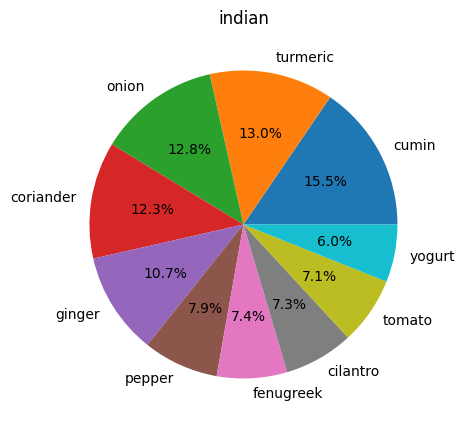

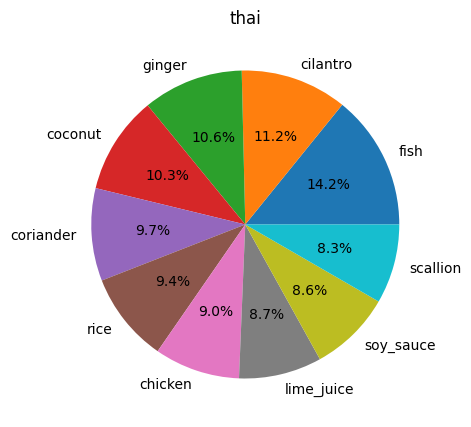

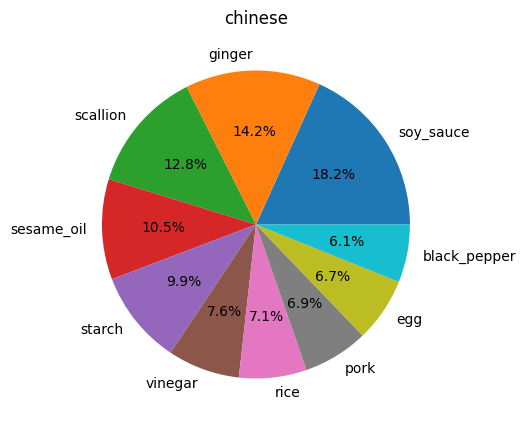

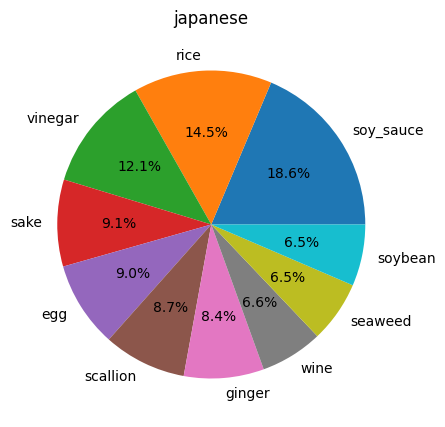

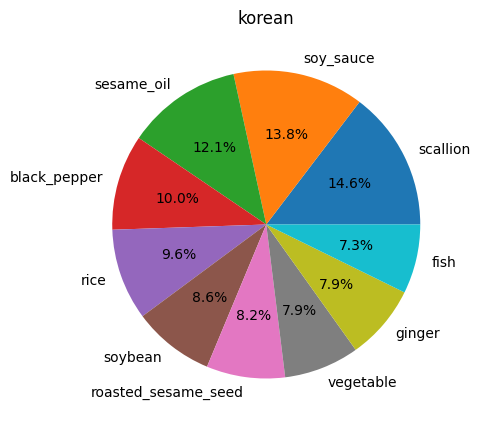

In [ ]:
# Step1: Get list of all cuisines
cuisines = df['cuisine'].unique()

# Step2: Loop through cuisines to plot pie chart for the number of ingredients used
for cuisine in cuisines:
    cuisine_df = df[df['cuisine'] == cuisine]

    ingredient_count = (cuisine_df.drop(['cuisine', 'Unnamed: 0'], axis=1).T != 0).sum(axis=1)

    top_ingredients = ingredient_count.sort_values(ascending=False).head(10)

    # Plot the pie chart
    plt.figure(figsize=(5, 5))
    top_ingredients.plot.pie(autopct='%1.1f%%')
    plt.title(cuisine)
    plt.ylabel('')
    plt.show()


Now analyse the plots, find the top 3 ingredients that are in almost all cuisins with high percentage and remove them from the dataframe

In [ ]:
top_3_ingredients = ['vegetable_oil', 'cayenne', 'garlic']

top3Removed_df = df.drop(columns=top_3_ingredients)

## **TASK5:**
separate the features from the lable (create a new dataframe for each). keep in mind to remove any other extra unnecessary columns from features

In [ ]:
features= df.drop(columns=['cuisine', 'Unnamed: 0'])
labels= df['cuisine']

print(features)

print(labels)


      almond  angelica  anise  anise_seed  apple  apple_brandy  apricot  \
0          0         0      0           0      0             0        0   
1          1         0      0           0      0             0        0   
2          0         0      0           0      0             0        0   
3          0         0      0           0      0             0        0   
4          0         0      0           0      0             0        0   
...      ...       ...    ...         ...    ...           ...      ...   
2443       0         0      0           0      0             0        0   
2444       0         0      0           0      0             0        0   
2445       0         0      0           0      0             0        0   
2446       0         0      0           0      0             0        0   
2447       0         0      0           0      0             0        0   

      armagnac  artemisia  artichoke  ...  whiskey  white_bread  white_wine  \
0            0      

Finally lets make sure the data is balanced, that is we have equal. number of instances for each cuisine using im

In [ ]:
!pip install imblearn

visit the imlearn website to learn more about the functions and modules.<br> <br>
what are possible ways to handle imbalanced data?<br>
Ans: **Oversampling**: adding more data to classes which are underrepresentaed. **Undersampling**: removing data from classes thare are overrepresented. You can also combine both under sampling and oversampling, as well as use using bagging and boosting for ensemble sampling. <br> <br>

what is SMOTE?May it add erroneous data?<br>
Ans: Syntethic minority over sampling Technique, is an oversampling methid that creates new syntehtic data and duplicates from the current data for minority classes, it uses K-nearest neighbour to create the data. Yes it can create erronous data if that dataset is messy and classes overlap. <br> <br>

what are the advantage and disadvantage of sampling? <br>
Ans: **Pros**: makes classes balanced, can improve accuracy for models using hard to gather data, easy to use. **Cons**: Methods such as Undersampling can cause you to lose useful data, SMOTE can also add noise that could cause problems. There may also be problems with overfitting as it is creating data to only match what we have. <br> <br>

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
print(labels.value_counts())

cuisine
korean      799
indian      598
chinese     442
japanese    320
thai        289
Name: count, dtype: int64


In [ ]:
sampling = SMOTE()
transformed_feature_df, transformed_label_df = sampling.\
fit_resample(features, labels)

show number off instances for each cuisine after sampling

In [ ]:
print(transformed_label_df.value_counts())

cuisine
indian      799
thai        799
chinese     799
japanese    799
korean      799
Name: count, dtype: int64


use pd.concat function to join the lables and features

In [ ]:
transformed_df=pd.concat([transformed_label_df, transformed_feature_df], axis=1)

print(transformed_df)

     cuisine  almond  angelica  anise  anise_seed  apple  apple_brandy  \
0     indian       0         0      0           0      0             0   
1     indian       1         0      0           0      0             0   
2     indian       0         0      0           0      0             0   
3     indian       0         0      0           0      0             0   
4     indian       0         0      0           0      0             0   
...      ...     ...       ...    ...         ...    ...           ...   
3990    thai       0         0      0           0      0             0   
3991    thai       0         0      0           0      0             0   
3992    thai       0         0      0           0      0             0   
3993    thai       0         0      0           0      0             0   
3994    thai       0         0      0           0      0             0   

      apricot  armagnac  artemisia  ...  whiskey  white_bread  white_wine  \
0           0         0          0

now save the data for next labs!

In [ ]:
transformed_df.to_csv("/content/cuisines_processed.csv")